## Comparison IS-RSA values Main vs. Replication Sample

*This script was used to assess the correspondance of region-specific IS-RSA values between the main and the replication sample (scatterplot and Pearson Correlation).* 

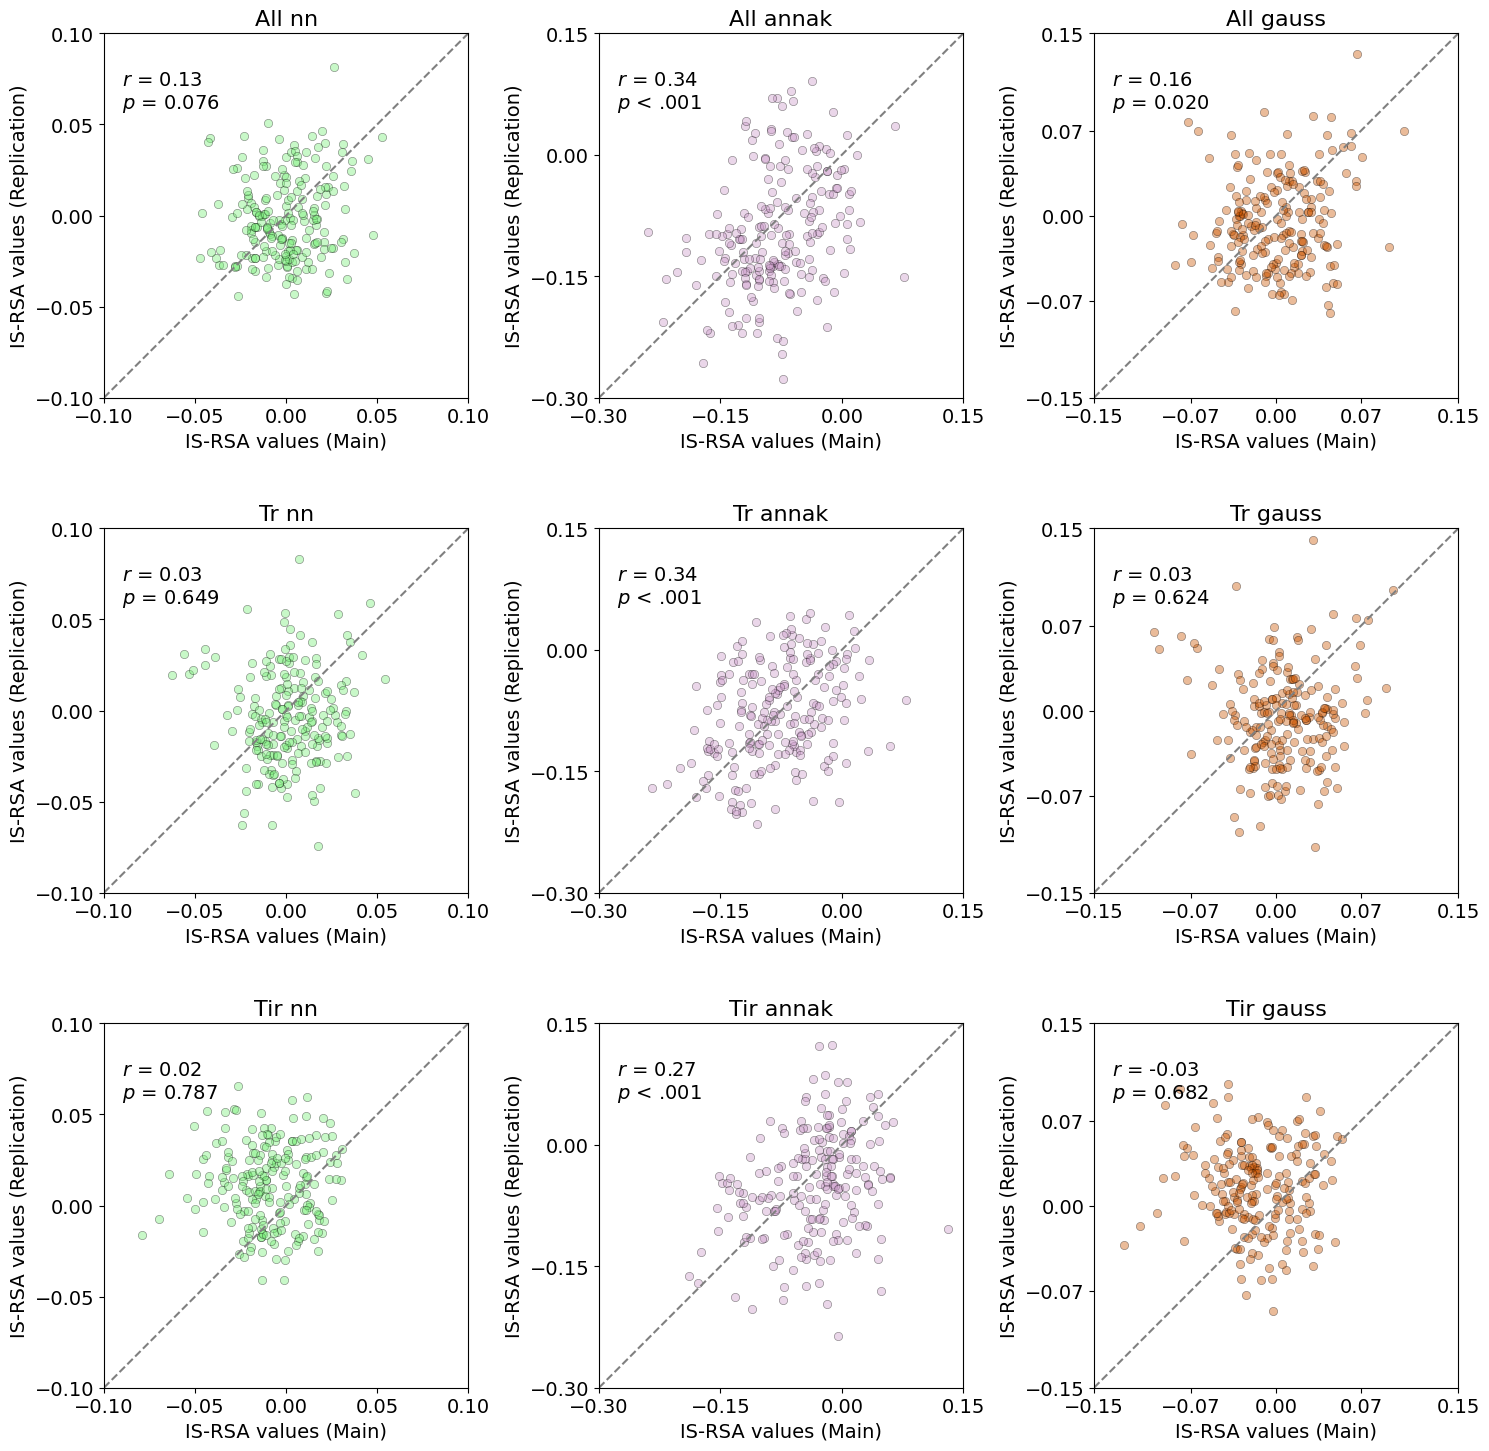

In [56]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
from scipy.stats import pearsonr

# Color and borders of axes accoring to type of model
plot_settings = {
    "_nn": {"color": "#77EE77", "xlim": (-0.10, 0.10), "ylim": (-0.10, 0.10)},
    "_annak": {"color": "#CB99C9", "xlim": (-0.30, 0.15), "ylim": (-0.30, 0.15)},
    "_gauss": {"color": "#CC5500", "xlim": (-0.15, 0.15), "ylim": (-0.15, 0.15)},
}

# Paths
main_dir = r"C:\Users\jop86ib\Documents\Paper 4\Results\IS_RSA_values"
rep_dir = r"C:\Users\jop86ib\Documents\Paper 4\Results\Replication\IS_RSA_values_replication"

# Filenames (w/o '_replication.csv')
file_names = [
    "IS_RSA_values_all_scenes_nn",
    "IS_RSA_values_all_scenes_annak",
    "IS_RSA_values_all_scenes_gauss",
    "IS_RSA_values_TR_scenes_nn",
    "IS_RSA_values_TR_scenes_annak",
    "IS_RSA_values_TR_scenes_gauss",
    "IS_RSA_values_TIR_scenes_nn",
    "IS_RSA_values_TIR_scenes_annak",
    "IS_RSA_values_TIR_scenes_gauss"
]

# Plot Setup
fig, axs = plt.subplots(3, 3, figsize=(15, 15))
axs = axs.flatten()

for idx, name in enumerate(file_names):
    # Load in csv's
    main_path = os.path.join(main_dir, name + ".csv")
    rep_path = os.path.join(rep_dir, name + "_replication.csv")

    df_main = pd.read_csv(main_path)
    df_rep = pd.read_csv(rep_path)

    # Find collumn with r-values 
    r_col_main = [col for col in df_main.columns if col.startswith("r_value")][0]
    r_col_rep = [col for col in df_rep.columns if col.startswith("r_value")][0]

    r_values_main = df_main[r_col_main]
    r_values_rep = df_rep[r_col_rep]

    # Define Type (nn, annak, gauss)
    for key in plot_settings:
        if key in name:
            settings = plot_settings[key]
            break

    # Compute Pearson Correlation
    r_val, p_val = pearsonr(r_values_main, r_values_rep)

    # Plot
    ax = axs[idx]
    ax.scatter(
        r_values_main,
        r_values_rep,
        alpha=0.4,
        color=settings["color"],
        edgecolors='black',
        linewidths=0.5
    )

    # Diagonal
    line = mlines.Line2D([0, 1], [0, 1], color='gray', linestyle='--', transform=ax.transAxes)
    ax.add_line(line)

    # Set axis borders and relation
    ax.set_xlim(settings["xlim"])
    ax.set_ylim(settings["ylim"])
    ax.set_aspect('equal')

    # Titke and Axes - Naming 
    ax.set_title(name.replace("IS_RSA_values_", "").replace("_scenes", "").replace("_", " ").capitalize(), fontsize=16)
    ax.set_xlabel("IS-RSA values (Main)", fontsize=14)
    ax.set_ylabel("IS-RSA values (Replication)", fontsize=14)

    # Set Ticks
    ax.tick_params(labelsize=14)
    if "_nn" in name:
        ax.set_xticks([-0.1, -0.05, 0, 0.05, 0.1])
        ax.set_yticks([-0.1, -0.05, 0, 0.05, 0.1])
    elif "_annak" in name:
        ax.set_xticks([-0.3, -0.15, 0, 0.15])
        ax.set_yticks([-0.3, -0.15, 0, 0.15])
    elif "_gauss" in name:
        ax.set_xticks([-0.15, -0.07, 0, 0.07, 0.15])
        ax.set_yticks([-0.15, -0.07, 0, 0.07, 0.15])

    # Insert correlations K(r and p-Value)
    if p_val < 0.001:
        p_text = "$p$ < .001"
    else:
        p_text = f"$p$ = {p_val:.3f}"

    ax.text(
        0.05, 0.9,
        f"$r$ = {r_val:.2f}\n{p_text}",
        transform=ax.transAxes,
        fontsize=14,
        verticalalignment='top'
    )

plt.tight_layout()
plt.tight_layout()
fig.savefig(r"C:\Users\jop86ib\Documents\Paper 4\Results\Replication\Figures\Comparison_IS_RSA_values_main_replication_sample.png", dpi=300, bbox_inches='tight')
plt.show()

plt.show()